In [ ]:
from google.colab import drive
drive.mount('/content/drive')

1.ABPM이 포함된 수면 (워치, 링, ABPM) 비교

“Ring(200Hz) 시간축을 제대로 복원한 뒤, Watch–Ring HR(1Hz) cross-correlation으로 실제 동기화(shift)를 잡아서 두 기기의 HR이 1.23 bpm 수준으로 거의 일치한다는 검증 결과”


이전(+277s): Ring의 timestamp를 epoch로 오인/절대시간 복원 실패 → C 구간 절단이 안 되고, 겹치는 구간이 흐트러진 상태에서 cross-corr가 큰 가짜 시프트를 찾아버린 결과(신뢰 낮음, corr도 낮음).

현재(+4s): Ring의 timestamp를 relative us로 올바르게 해석 → C도 AB S-CUT이 제대로 적용, 동일 구간에서 HR(1Hz)로 cross-corr 정렬하니 **작은 실제 시프트(+4초)**만 남고, MAE 1.23 bpm / bias -0.23 bpm로 “측정 불확실성 수준의 일치”가 나온 결과(신뢰 높음).

PPG Analysis - Watch (25Hz) vs Ring (200Hz)


/tmp/ipython-input-1345377539.py:250: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt_try = pd.to_datetime(df[c], errors="coerce")



[ABPM] 93 events
  Time range: 2025-09-13 01:30:00 ~ 2025-09-14 22:00:00
[Watch] shape=(144000, 6), columns=['timestamp', 'time', 'ppg', 'acc_x', 'acc_y', 'acc_z']
[Watch] Time range: 2025-09-13 01:24:01.055000 ~ 2025-09-13 09:00:03.383000
[Ring] shape=(5599248, 2), ppg_col=1, time_col=0
[Ring] First 5 timestamp values: [950966, 956199, 961432, 966665, 971898]
  DateTime parsing: 100.0% valid
  1970 year ratio: 100.0%
  Rejecting datetime parsing (too many 1970 dates, likely wrong)
  Attempting numeric timestamp parsing...
  Detected timestamp unit: us (divisor=1e+06, median_diff=5380.00)
  Using start_time: 2025-09-13 01:24:00
[Ring] Time range: 2025-09-13 01:24:00 ~ 2025-09-13 09:07:02.519108

[Common Period] 2025-09-13 01:30:00 ~ 2025-09-13 09:00:03.383000
  Duration: 7.50 hours

[Cut Data]
  Watch: 135076 samples (5403.0s)
  Ring:  5442202 samples (27211.0s)
  ABPM:  16 events

[Extracting beat features...]
  Watch beats: 5890
  Ring beats:  29419

[Result: Watch vs Ring Correlati

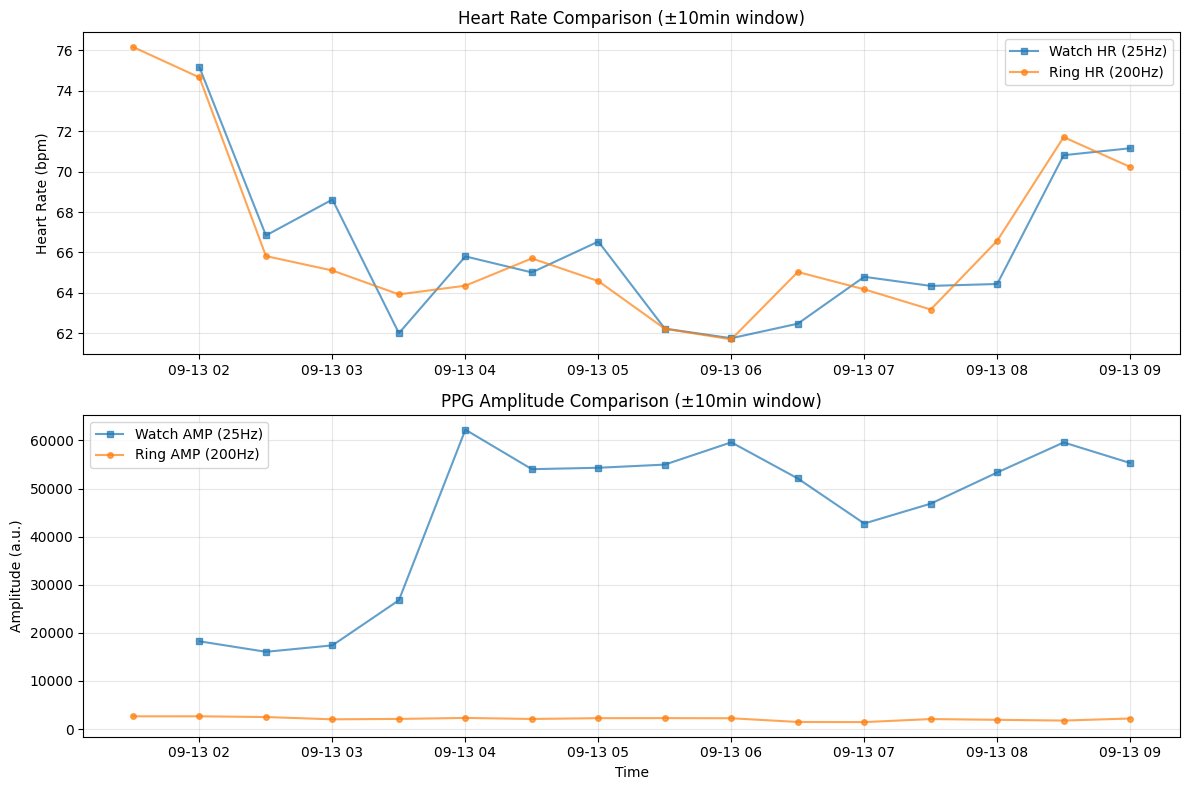

[Results saved: ppg_watch_ring_results.csv]

Analysis Complete!


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend, find_peaks

# ============================================================
# CONFIG
# ============================================================
# **Watch (25Hz) - 새 포맷 E0001**
WATCH_CSV = "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001_Day2_cut_202509130124_202509130907.csv"
FS_WATCH = 25.0

# **Ring (200Hz) - 기존 포맷**
RING_CSV = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw2.csv"
FS_RING = 200.0
RING_START_TIME = "2025-09-13 01:24:00"

# **ABPM**
ABPM_XLSX = "/content/drive/MyDrive/Colab Notebooks/PPG_REAL/PWV1.xlsx"

MIN_BPM = 40
MAX_BPM = 200
PROM_SCALE_RING = 0.2
PROM_SCALE_WATCH = 0.1
ABPM_WIN_MIN = 10
MIN_BEATS_IN_WIN = 10

# ============================================================
# FUNCTIONS
# ============================================================

def read_csv_robust(path: str) -> pd.DataFrame:
    """CSV 읽기 - 헤더 자동 감지"""
    df = pd.read_csv(path)
    def is_numberish(x):
        try:
            float(str(x).strip())
            return True
        except: return False
    if df.shape[1] >= 2 and all(is_numberish(c) for c in df.columns):
        df = pd.read_csv(path, header=None)
    return df

def pick_time_col(df: pd.DataFrame) -> str:
    """시간 컬럼 추정"""
    cand = ["time", "Time", "timestamp", "Timestamp", "sample_or_time", "sample_time", "t",
            "sample_index", "index", "Index"]
    for c in cand:
        if c in df.columns: return c
    return df.columns[0]

def infer_ppg_col(df: pd.DataFrame, time_col: str) -> str:
    """PPG 컬럼 추정 - 모션 센서 데이터 제외"""
    exclude_keywords = ['sleep', 'step', 'battery', 'quality', 'flag', 'stage',
                        'day', 'month', 'year', 'date', 'index', 'cnt', 'count',
                        'acc', 'gyro', 'motion', 'axis', '_x', '_y', '_z']

    candidates = []
    for c in df.columns:
        if c == time_col: continue
        if any(k in str(c).lower() for k in exclude_keywords): continue
        try:
            pd.to_numeric(df[c])
            candidates.append(c)
        except: pass

    num_cols = [c for c in candidates if pd.api.types.is_numeric_dtype(df[c])]

    if len(num_cols) == 0:
        num_cols = [c for c in df.columns if c != time_col and pd.api.types.is_numeric_dtype(df[c])]

    if len(num_cols) == 0:
        if df.shape[1] == 2: return df.columns[1]
        raise ValueError(f"PPG 컬럼 추정 실패. 컬럼명: {df.columns.tolist()}")

    return num_cols[0]  # 첫 번째 숫자 컬럼 (보통 PPG)

def build_datetime_smart(df: pd.DataFrame, time_col: str, fs: float, start_time: str = None) -> pd.Series:
    """
    시간 컬럼을 datetime으로 변환
    - 'time' 컬럼이 이미 datetime string이면 직접 파싱
    - 'timestamp' 같은 숫자 컬럼이면 자동 단위 감지 + start_time 적용
    """
    # 먼저 datetime string으로 파싱 시도
    dt_try = pd.to_datetime(df[time_col], errors="coerce")
    valid_ratio = dt_try.notna().sum() / len(df)

    print(f"  DateTime parsing: {valid_ratio*100:.1f}% valid")

    # 단, 1970년대 날짜는 잘못된 파싱일 가능성 높음 (Unix epoch 0 근처)
    if valid_ratio > 0.9:
        valid_dates = dt_try[dt_try.notna()]
        if len(valid_dates) > 0:
            year_1970_ratio = (valid_dates.dt.year == 1970).sum() / len(valid_dates)
            print(f"  1970 year ratio: {year_1970_ratio*100:.1f}%")

            if year_1970_ratio < 0.5:  # 1970년이 50% 미만이면 유효한 datetime
                print(f"  Using direct datetime parsing (non-1970 dates)")
                return dt_try
            else:
                print(f"  Rejecting datetime parsing (too many 1970 dates, likely wrong)")

    # 숫자 타임스탬프로 변환 시도
    print(f"  Attempting numeric timestamp parsing...")
    ts = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)
    ts = np.asarray(ts, dtype=float)
    valid_ts = ts[np.isfinite(ts)]
    if len(valid_ts) < 100:
        raise ValueError(f"유효한 타임스탬프가 너무 적습니다: {len(valid_ts)}")

    diffs = np.diff(valid_ts[:min(1000, len(valid_ts))])
    diffs = diffs[diffs > 0]

    unit, divisor = 's', 1.0
    if len(diffs) > 0:
        median_diff = np.median(diffs)
        expected_interval = 1.0 / fs

        # 단위 자동 감지 (fs 기반)
        if abs(median_diff - expected_interval * 1e9) < expected_interval * 1e9 * 0.5:
            unit, divisor = 'ns', 1e9
        elif abs(median_diff - expected_interval * 1e6) < expected_interval * 1e6 * 0.5:
            unit, divisor = 'us', 1e6
        elif abs(median_diff - expected_interval * 1e3) < expected_interval * 1e3 * 0.5:
            unit, divisor = 'ms', 1e3
        elif abs(median_diff - expected_interval) < expected_interval * 0.5:
            unit, divisor = 's', 1.0
        elif abs(median_diff - 1.0) < 0.5:
            unit, divisor = 'samples', fs
        else:
            # 경험적 추정
            if median_diff > 1e6:
                unit, divisor = 'ns', 1e9
            elif median_diff > 1000:
                unit, divisor = 'us', 1e6
            elif median_diff > 1:
                unit, divisor = 'ms', 1e3
            else:
                unit, divisor = 's', 1.0

    print(f"  Detected timestamp unit: {unit} (divisor={divisor:.0e}, median_diff={np.median(diffs) if len(diffs)>0 else 0:.2f})")

    t_seconds = (ts - ts[0]) / divisor
    t_seconds = np.nan_to_num(t_seconds, nan=0.0)

    # start_time 필수 (기본값 사용하지 않음)
    if start_time is None:
        raise ValueError("숫자 타임스탬프는 start_time이 필요합니다!")

    print(f"  Using start_time: {start_time}")
    dt = pd.to_datetime(start_time) + pd.to_timedelta(t_seconds, unit='s')
    return pd.Series(dt)

def preprocess_ppg(x: np.ndarray, fs: float) -> np.ndarray:
    """
    PPG 전처리: detrend + bandpass filter
    짧은 신호 대응: 필터링 전 길이 체크
    """
    # NaN 처리
    if np.any(~np.isfinite(x)):
        x = pd.Series(x).interpolate(limit_direction="both").to_numpy(dtype=float)

    # 신호 길이 체크
    if len(x) < 50:  # 너무 짧으면 필터링 스킵
        print(f"[WARNING] Signal too short ({len(x)} samples), skipping filtering")
        return x - np.mean(x)

    try:
        # Detrend
        x0 = detrend(x)

        # Bandpass filter 설계
        nyq = 0.5 * fs
        lo = max((MIN_BPM/60.0) / nyq, 1e-6)
        hi = min((MAX_BPM/60.0) / nyq, 0.999)
        b, a = butter(2 if fs < 50 else 4, [lo, hi], btype="band")

        # Filtfilt padding 체크
        default_padlen = 3 * max(len(b), len(a))

        if len(x0) <= default_padlen:
            # 짧은 신호: padding 줄이기
            if len(x0) <= 2 * len(b):
                print(f"[WARNING] Signal too short ({len(x0)} samples) for bandpass, returning detrended")
                return x0
            else:
                padlen = min(default_padlen, len(x0) - 1)
                print(f"[WARNING] Short signal ({len(x0)} samples), using reduced padlen={padlen}")
                return filtfilt(b, a, x0, padlen=padlen)
        else:
            # 정상 필터링
            return filtfilt(b, a, x0)

    except Exception as e:
        print(f"[WARNING] Filtering failed: {e}, returning mean-centered signal")
        return x - np.mean(x)

def extract_beat_features(dt: pd.Series, ppg: np.ndarray, fs: float, prom_scale: float) -> pd.DataFrame:
    """PPG에서 박동 특징 추출"""
    y = preprocess_ppg(ppg, fs)
    t_sec = np.arange(len(y), dtype=float) / fs
    min_dist = int(round((60.0 / MAX_BPM) * fs))
    base_prom = prom_scale * np.nanstd(y)

    try:
        peaks, _ = find_peaks(y, distance=max(1, min_dist), prominence=base_prom)
        troughs, _ = find_peaks(-y, distance=max(1, min_dist), prominence=base_prom * 0.5)
    except:
        return pd.DataFrame(columns=["dt", "HR", "AMP", "RISE", "AREA"])

    if len(peaks) < 3 or len(troughs) < 3:
        return pd.DataFrame(columns=["dt", "HR", "AMP", "RISE", "AREA"])

    peaks = np.sort(peaks)
    troughs = np.sort(troughs)
    rows = []

    if not isinstance(dt, pd.Series):
        dt = pd.Series(dt)

    for j in range(len(troughs) - 1):
        iL, iR = troughs[j], troughs[j+1]
        if iR <= iL + 2: continue
        m = (peaks > iL) & (peaks < iR)
        if m.sum() == 0: continue
        iP = peaks[m][np.argmax(y[peaks[m]])]

        dt_beat = t_sec[iR] - t_sec[iL]
        if dt_beat <= 0: continue
        hr = 60.0 / dt_beat
        if not (MIN_BPM <= hr <= MAX_BPM): continue

        if pd.notna(dt.iloc[iP]):
            rows.append({
                "dt": dt.iloc[iP],
                "HR": hr,
                "AMP": y[iP] - y[iL],
                "RISE": t_sec[iP] - t_sec[iL],
                "AREA": np.trapezoid(y[iL:iR+1] - y[iL], t_sec[iL:iR+1])
            })
    return pd.DataFrame(rows)

def load_abpm_xlsx(path: str) -> pd.DataFrame:
    """ABPM Excel 로드"""
    df = pd.read_excel(path)
    dt_col = None
    best_valid = -1

    for c in df.columns:
        dt_try = pd.to_datetime(df[c], errors="coerce")
        valid_count = dt_try.notna().sum()
        if valid_count < 3: continue
        valid_years = dt_try.dt.year
        real_date_ratio = (valid_years >= 2000).sum() / valid_count
        if valid_count > best_valid and real_date_ratio > 0.5:
            best_valid = valid_count
            dt_col = c

    if dt_col is None:
        cols = list(df.columns)
        for c1 in cols:
            for c2 in cols:
                if c1 == c2: continue
                dt_try = pd.to_datetime(df[c1].astype(str) + " " + df[c2].astype(str), errors="coerce")
                valid_count = dt_try.notna().sum()
                if valid_count < 3: continue
                valid_years = dt_try.dt.year
                real_date_ratio = (valid_years >= 2000).sum() / valid_count
                if valid_count > best_valid and real_date_ratio > 0.5:
                    best_valid = valid_count
                    dt_col = (c1, c2)

    if isinstance(dt_col, tuple):
        dt = pd.to_datetime(df[dt_col[0]].astype(str) + " " + df[dt_col[1]].astype(str), errors="coerce")
    else:
        dt = pd.to_datetime(df[dt_col], errors="coerce")

    df["dt"] = dt
    df = df.dropna(subset=["dt"]).sort_values("dt").reset_index(drop=True)

    def pick(k):
        for c in df.columns:
            if k.lower() in str(c).lower(): return c
        return None

    mapping = {
        "SBP": pick("SBP") or pick("SYS"),
        "DBP": pick("DBP") or pick("DIA"),
        "MAP": pick("MAP")
    }
    out = df[["dt"] + [v for v in mapping.values() if v]].rename(columns={v:k for k,v in mapping.items()})
    for c in out.columns:
        if c != "dt":
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def load_watch_new_format(csv_path: str, fs: float) -> tuple:
    """
    Watch 새 포맷 로드 (time, ppg, acc_x/y/z 컬럼 있음)
    Returns: (datetime_series, ppg_array)
    """
    df = pd.read_csv(csv_path)
    print(f"[Watch] shape={df.shape}, columns={df.columns.tolist()}")

    # 'time' 컬럼이 이미 datetime string 형태
    if 'time' in df.columns:
        dt = pd.to_datetime(df['time'], errors='coerce')
        print(f"[Watch] Time range: {dt.min()} ~ {dt.max()}")
    else:
        raise ValueError(f"'time' 컬럼이 없습니다: {df.columns.tolist()}")

    # 'ppg' 컬럼
    if 'ppg' in df.columns:
        ppg = pd.to_numeric(df['ppg'], errors='coerce').to_numpy(dtype=float)
    else:
        raise ValueError(f"'ppg' 컬럼이 없습니다: {df.columns.tolist()}")

    return dt, ppg

def load_ring_old_format(csv_path: str, fs: float, start_time: str, target_col=None) -> tuple:
    """
    Ring 기존 포맷 로드 (숫자 timestamp, start_time 필요)
    Returns: (datetime_series, ppg_array)
    """
    df = read_csv_robust(csv_path)
    time_col = pick_time_col(df)

    if target_col and target_col in df.columns:
        ppg_col = target_col
    elif target_col and target_col.isdigit():
        ppg_col = df.columns[int(target_col)]
    else:
        ppg_col = infer_ppg_col(df, time_col)

    print(f"[Ring] shape={df.shape}, ppg_col={ppg_col}, time_col={time_col}")
    print(f"[Ring] First 5 timestamp values: {df[time_col].head().tolist()}")

    dt = build_datetime_smart(df, time_col, fs, start_time)
    ppg = pd.to_numeric(df[ppg_col], errors="coerce").to_numpy(dtype=float)
    print(f"[Ring] Time range: {dt.min()} ~ {dt.max()}")
    return dt, ppg

# ============================================================
# MAIN
# ============================================================
print("="*80)
print("PPG Analysis - Watch (25Hz) vs Ring (200Hz)")
print("="*80)

# 1. Load ABPM
abpm = load_abpm_xlsx(ABPM_XLSX)
print(f"\n[ABPM] {len(abpm)} events")
print(f"  Time range: {abpm['dt'].min()} ~ {abpm['dt'].max()}")

# 2. Load Watch (새 포맷 25Hz)
dt_watch, ppg_watch = load_watch_new_format(WATCH_CSV, FS_WATCH)

# 3. Load Ring (기존 포맷 200Hz)
dt_ring, ppg_ring = load_ring_old_format(RING_CSV, FS_RING, RING_START_TIME, target_col="1")

# 4. Common Period
start = max(abpm['dt'].min(), dt_watch.min(), dt_ring.min())
end = min(abpm['dt'].max(), dt_watch.max(), dt_ring.max())
print(f"\n[Common Period] {start} ~ {end}")
print(f"  Duration: {(end - start).total_seconds() / 3600:.2f} hours")

if (end - start).total_seconds() <= 0:
    raise ValueError("시간대가 겹치지 않습니다. ABPM/Watch/Ring 시간 설정을 확인해주세요.")

# 5. Cut to Common Period
m_watch = (dt_watch >= start) & (dt_watch <= end)
m_ring = (dt_ring >= start) & (dt_ring <= end)
m_abpm = (abpm['dt'] >= start) & (abpm['dt'] <= end)

dt_watch_cut = pd.Series(dt_watch[m_watch]).reset_index(drop=True)
ppg_watch_cut = ppg_watch[m_watch]

dt_ring_cut = pd.Series(dt_ring[m_ring]).reset_index(drop=True)
ppg_ring_cut = ppg_ring[m_ring]

abpm_cut = abpm[m_abpm].reset_index(drop=True)

print(f"\n[Cut Data]")
print(f"  Watch: {len(ppg_watch_cut)} samples ({len(ppg_watch_cut)/FS_WATCH:.1f}s)")
print(f"  Ring:  {len(ppg_ring_cut)} samples ({len(ppg_ring_cut)/FS_RING:.1f}s)")
print(f"  ABPM:  {len(abpm_cut)} events")

# 6. Extract Beat Features
print("\n[Extracting beat features...]")
beats_watch = extract_beat_features(dt_watch_cut, ppg_watch_cut, FS_WATCH, PROM_SCALE_WATCH)
beats_ring = extract_beat_features(dt_ring_cut, ppg_ring_cut, FS_RING, PROM_SCALE_RING)
print(f"  Watch beats: {len(beats_watch)}")
print(f"  Ring beats:  {len(beats_ring)}")

# 7. Match with ABPM
def match_beats(beats, abpm_df):
    """ABPM 각 시점에서 전후 10분 평균 특징 계산"""
    res = []
    for t in abpm_df["dt"]:
        sub = beats[(beats["dt"] >= t - pd.Timedelta(minutes=ABPM_WIN_MIN)) &
                    (beats["dt"] <= t + pd.Timedelta(minutes=ABPM_WIN_MIN))]
        if len(sub) < MIN_BEATS_IN_WIN:
            res.append({k: np.nan for k in ["HR_mean", "AMP_mean"]})
        else:
            res.append({
                "HR_mean": sub["HR"].mean(),
                "AMP_mean": sub["AMP"].mean()
            })
    return pd.DataFrame(res)

f_watch = match_beats(beats_watch, abpm_cut)
f_ring = match_beats(beats_ring, abpm_cut)

compare = pd.concat([
    abpm_cut,
    f_watch.add_suffix("_watch"),
    f_ring.add_suffix("_ring")
], axis=1)

# 8. Correlation Analysis
print("\n" + "="*80)
print("[Result: Watch vs Ring Correlation]")
print("="*80)
for f in ["HR_mean", "AMP_mean"]:
    valid = compare[[f"{f}_watch", f"{f}_ring"]].dropna()
    if len(valid) > 2:
        r = np.corrcoef(valid[f"{f}_watch"], valid[f"{f}_ring"])[0, 1]
        print(f"  {f:12s}: n={len(valid):3d}, r={r:+.3f}")
    else:
        print(f"  {f:12s}: Not enough data (n={len(valid)})")

# 9. Visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: HR Comparison
ax = axes[0]
if "HR_mean_watch" in compare.columns and compare["HR_mean_watch"].notna().sum() > 0:
    ax.plot(compare["dt"], compare["HR_mean_watch"], 's-', label="Watch HR (25Hz)", alpha=0.7, markersize=4)
if "HR_mean_ring" in compare.columns and compare["HR_mean_ring"].notna().sum() > 0:
    ax.plot(compare["dt"], compare["HR_mean_ring"], 'o-', label="Ring HR (200Hz)", alpha=0.7, markersize=4)
ax.set_ylabel("Heart Rate (bpm)")
ax.set_title("Heart Rate Comparison (±10min window)")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Amplitude Comparison
ax = axes[1]
if "AMP_mean_watch" in compare.columns and compare["AMP_mean_watch"].notna().sum() > 0:
    ax.plot(compare["dt"], compare["AMP_mean_watch"], 's-', label="Watch AMP (25Hz)", alpha=0.7, markersize=4)
if "AMP_mean_ring" in compare.columns and compare["AMP_mean_ring"].notna().sum() > 0:
    ax.plot(compare["dt"], compare["AMP_mean_ring"], 'o-', label="Ring AMP (200Hz)", alpha=0.7, markersize=4)
ax.set_ylabel("Amplitude (a.u.)")
ax.set_xlabel("Time")
ax.set_title("PPG Amplitude Comparison (±10min window)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ppg_watch_ring_comparison.png", dpi=150, bbox_inches='tight')
print("\n[Plot saved: ppg_watch_ring_comparison.png]")
plt.show()

# 10. Save Results
compare.to_csv("ppg_watch_ring_results.csv", index=False)
print("[Results saved: ppg_watch_ring_results.csv]")
print("\n" + "="*80)
print("Analysis Complete!")
print("="*80)

2. 25hz와 200hz에서 각각 HRV 뽑아서 품질비교

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt

# ============================================================
# Watch (25Hz) vs Ring (200Hz): 5-min HRV + nNN filtering + RR errors + RMSSD Bland-Altman
# ============================================================

CFG = {
    # [FILES]
    "FILE_WATCH": "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001_Day2_cut_202509130124_202509130907.csv",
    "FILE_RING": "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw2.csv",

    # [ANALYSIS RANGE]
    "START": "2025-09-13 01:24:00",
    "END":   "2025-09-13 09:00:00",

    # [COLUMNS]
    "PPG_COL_WATCH": "ppg",
    "SPO2_COL_WATCH": None,  # E0001에 SpO2 없으면 None

    "READ_RING_HEADER_NONE": True,
    "T_COL_RING": 0,
    "PPG_COL_RING": 1,
    "SPO2_COL_RING": None,
    "T_UNIT_RING": "us",  # 'us': relative microseconds anchored at START

    # [SAMPLING RATES]
    "FS_WATCH": 25.0,
    "FS_RING": 200.0,
    "RING_START_TIME": "2025-09-13 01:24:00",

    # [WINDOW]  ★ HRV는 5분 권장
    "WIN_SEC": 300,     # 5 minutes
    "STEP_SEC": 60,     # 1 minute step

    # [QC]
    "MIN_VALID_RATIO_WATCH": 0.70,
    "MIN_VALID_RATIO_RING": 0.90,
    "MIN_SNR_DB": -10.0,

    # [Physiology]
    "HR_MIN": 40,
    "HR_MAX": 180,
    "RR_MIN_MS": 300,
    "RR_MAX_MS": 1500,
    "RR_DEV_FROM_MED_FRAC": 0.20,   # median 대비 20% 이상 벗어나면 제외

    # [HRV reliability]
    "MIN_NN_FOR_RMSSD": 30,          # ★ nNN < 30이면 RMSSD 제외

    # [RR matching & error]
    "PEAK_MATCH_TOL_MS": 150,        # Watch 피크 vs Ring 피크 매칭 허용 오차
    "RR_OUTLIER_MS": 50,             # RR error outlier 정의: |err| > 50ms

    # [Bootstrap CI for RMSSD]
    "RMSSD_BOOTSTRAP": True,
    "RMSSD_BOOT_N": 300,
    "RMSSD_BOOT_MIN_DIFF": 20,

    # [OUTPUT]
    "OUT_DIR": "/content/drive/MyDrive/Colab Notebooks/results_hrv_watch_ring",
    "RUN_ID": "hrv_5min_rrerr_rmssdBA",
}
os.makedirs(CFG["OUT_DIR"], exist_ok=True)


# ============================================================
# Helpers
# ============================================================
def robust_mad(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    med = np.median(x)
    return 1.4826 * np.median(np.abs(x - med)) + 1e-12

def bandpass_filter(data, fs, lowcut=0.5, highcut=5.0, order=2):
    data = np.asarray(data, float)
    if np.isfinite(data).sum() < max(int(fs * 2), 10):
        return data
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    try:
        fill = np.nanmedian(data[np.isfinite(data)]) if np.any(np.isfinite(data)) else 0.0
        return filtfilt(b, a, np.nan_to_num(data, nan=fill))
    except Exception:
        return data

def calc_snr(x, fs):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) < fs * 2:
        return np.nan
    x = x - np.mean(x)
    n = len(x)
    freq = np.fft.rfftfreq(n, d=1/fs)
    mag = np.abs(np.fft.rfft(x * np.hanning(n)))**2

    sig_mask = (freq >= 0.5) & (freq <= 4.0)
    noise_mask = ((freq >= 0.1) & (freq < 0.5)) | ((freq > 4.0) & (freq <= 10.0))

    s_power = np.sum(mag[sig_mask])
    n_power = np.sum(mag[noise_mask])
    if n_power <= 0:
        return 50.0
    return 10 * np.log10(s_power / n_power)

def detect_peaks(sig, fs):
    """
    return: peaks_idx (in sig_filt array), sig_filt (aligned to finite-only input)
    """
    sig = np.asarray(sig, float)
    sig = sig[np.isfinite(sig)]
    if len(sig) < fs * 8:
        return np.array([], dtype=int), sig

    x = bandpass_filter(sig, fs)
    x = x - np.median(x)
    s = robust_mad(x)
    if not np.isfinite(s) or s <= 0:
        return np.array([], dtype=int), x

    min_dist = int(fs * (60.0 / max(CFG["HR_MAX"], 1)))
    min_dist = max(min_dist, 1)
    prom = 0.8 * s
    p, _ = find_peaks(x, distance=min_dist, prominence=prom)
    return p.astype(int), x

def compute_nn_metrics_from_peaks(peaks_idx, fs):
    """
    peaks_idx: indices in the (finite-only) signal array
    returns:
      hr_bpm (median RR), rmssd_ms (if nNN>=MIN_NN_FOR_RMSSD else NaN),
      nn_ms, rr_removed_ratio, counts dict, rmssd_ci_low/high
    """
    if len(peaks_idx) < 4:
        return np.nan, np.nan, np.array([]), np.nan, {"n_peaks": int(len(peaks_idx)), "n_rr_raw": 0, "n_nn": 0}, (np.nan, np.nan)

    rr_ms_raw = np.diff(peaks_idx) / fs * 1000.0
    n_rr_raw = len(rr_ms_raw)

    # 1) physiological bounds
    m1 = (rr_ms_raw >= CFG["RR_MIN_MS"]) & (rr_ms_raw <= CFG["RR_MAX_MS"])
    rr_ms_1 = rr_ms_raw[m1]

    # 2) median deviation
    if len(rr_ms_1) >= 3:
        med = np.median(rr_ms_1)
        m2 = np.abs(rr_ms_1 - med) <= (CFG["RR_DEV_FROM_MED_FRAC"] * med)
        nn = rr_ms_1[m2]
    else:
        nn = np.array([])

    n_nn = len(nn)
    rr_removed_ratio = 1.0 - (n_nn / max(n_rr_raw, 1))

    hr = np.nan
    rmssd = np.nan
    ci_lo, ci_hi = np.nan, np.nan

    if n_nn >= 3:
        hr = 60000.0 / np.median(nn)

    # RMSSD only if enough NN
    if n_nn >= CFG["MIN_NN_FOR_RMSSD"]:
        diff_nn = np.diff(nn)
        if len(diff_nn) > 0:
            rmssd = float(np.sqrt(np.mean(diff_nn**2)))

            # bootstrap CI
            if CFG["RMSSD_BOOTSTRAP"] and (len(diff_nn) >= CFG["RMSSD_BOOT_MIN_DIFF"]):
                B = int(CFG["RMSSD_BOOT_N"])
                boot = np.empty(B, float)
                for b in range(B):
                    samp = np.random.choice(diff_nn, size=len(diff_nn), replace=True)
                    boot[b] = np.sqrt(np.mean(samp**2))
                ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])

    counts = {"n_peaks": int(len(peaks_idx)), "n_rr_raw": int(n_rr_raw), "n_nn": int(n_nn)}
    return float(hr), rmssd, nn, float(rr_removed_ratio), counts, (float(ci_lo), float(ci_hi))

def match_peaks_by_time(tA, tB, tol_ms):
    """
    tA, tB: peak times in seconds (sorted)
    returns matched indices in A and B (same length)
    greedy two-pointer matching
    """
    tol = tol_ms / 1000.0
    i = j = 0
    mA, mB = [], []
    while i < len(tA) and j < len(tB):
        dt = tA[i] - tB[j]
        if abs(dt) <= tol:
            mA.append(i); mB.append(j)
            i += 1; j += 1
        else:
            if tA[i] < tB[j]:
                i += 1
            else:
                j += 1
    return np.array(mA, int), np.array(mB, int)

def load_watch_new_format(csv_path):
    """Watch 새 포맷 로드 (time, ppg 컬럼)"""
    df = pd.read_csv(csv_path)
    print(f"[Watch] shape={df.shape}, columns={df.columns.tolist()}")

    if 'time' in df.columns:
        dt = pd.to_datetime(df['time'], errors='coerce')
    else:
        raise ValueError(f"'time' 컬럼이 없습니다")

    if 'ppg' in df.columns:
        ppg = pd.to_numeric(df['ppg'], errors='coerce').to_numpy(dtype=float)
    else:
        raise ValueError(f"'ppg' 컬럼이 없습니다")

    spo2 = np.full(len(df), np.nan)
    if CFG["SPO2_COL_WATCH"] and CFG["SPO2_COL_WATCH"] in df.columns:
        spo2 = pd.to_numeric(df[CFG["SPO2_COL_WATCH"]], errors='coerce').to_numpy()

    return dt, ppg, spo2

def load_ring_old_format(csv_path, start_time):
    """Ring 기존 포맷 로드 (마이크로초 timestamp)"""
    df = pd.read_csv(csv_path, header=None if CFG["READ_RING_HEADER_NONE"] else 0)
    print(f"[Ring] shape={df.shape}")

    t_val = pd.to_numeric(df[CFG["T_COL_RING"]], errors="coerce")
    ppg = pd.to_numeric(df[CFG["PPG_COL_RING"]], errors='coerce').to_numpy(dtype=float)

    spo2 = np.full(len(df), np.nan)
    if CFG["SPO2_COL_RING"] is not None and df.shape[1] > CFG["SPO2_COL_RING"]:
        spo2 = pd.to_numeric(df[CFG["SPO2_COL_RING"]], errors='coerce').to_numpy()

    # 마이크로초 변환
    if CFG["T_UNIT_RING"] == "us":
        t_sec = (t_val - t_val.iloc[0]) / 1e6
        dt = pd.to_datetime(start_time) + pd.to_timedelta(t_sec, unit='s')
    else:
        dt = pd.to_datetime(t_val, unit=CFG["T_UNIT_RING"], errors="coerce")

    return dt, ppg, spo2


# ============================================================
# Load data
# ============================================================
print("="*80)
print("🫀 HRV Analysis: Watch (25Hz) vs Ring (200Hz)")
print("   5-min windows + nNN filtering + RR errors + RMSSD Bland-Altman")
print("="*80)

t0 = pd.to_datetime(CFG["START"])
t1 = pd.to_datetime(CFG["END"])

print(f"\n📅 Analysis Range:")
print(f"   {t0} ~ {t1}")
print(f"   Duration: {(t1-t0).total_seconds()/3600:.2f} hours")

# Load Watch
print(f"\n📂 Loading Watch...")
dt_watch_full, x_watch_full, s_watch_full = load_watch_new_format(CFG["FILE_WATCH"])
print(f"   Time range: {dt_watch_full.min()} ~ {dt_watch_full.max()}")

# Load Ring
print(f"\n📂 Loading Ring...")
dt_ring_full, x_ring_full, s_ring_full = load_ring_old_format(CFG["FILE_RING"], CFG["RING_START_TIME"])
print(f"   Time range: {dt_ring_full.min()} ~ {dt_ring_full.max()}")

# Cut to analysis range
m_watch = (dt_watch_full >= t0) & (dt_watch_full <= t1)
m_ring = (dt_ring_full >= t0) & (dt_ring_full <= t1)

dt_watch = pd.to_datetime(dt_watch_full[m_watch]).to_numpy()
x_watch = x_watch_full[m_watch.to_numpy()]
s_watch = s_watch_full[m_watch.to_numpy()]

dt_ring = pd.to_datetime(dt_ring_full[m_ring]).to_numpy()
x_ring = x_ring_full[m_ring.to_numpy()]
s_ring = s_ring_full[m_ring.to_numpy()]

# Convert to float seconds timestamps (sub-second precision)
ts_watch = (pd.to_datetime(dt_watch).astype("datetime64[ns]").astype(np.int64) / 1e9).astype(np.float64)
ts_ring = (pd.to_datetime(dt_ring).astype("datetime64[ns]").astype(np.int64) / 1e9).astype(np.float64)

print(f"\n📊 Samples in range:")
print(f"   Watch: {len(ts_watch):,} ({len(ts_watch)/CFG['FS_WATCH']:.1f}s)")
print(f"   Ring:  {len(ts_ring):,} ({len(ts_ring)/CFG['FS_RING']:.1f}s)")

# ============================================================
# Window loop (5-min)
# ============================================================
win_sec = float(CFG["WIN_SEC"])
step_sec = float(CFG["STEP_SEC"])
start_ts = float(t0.timestamp())
end_ts = float(t1.timestamp())

rows = []
rr_err_rows = []  # beat-to-beat RR error samples

cur = start_ts
wid = 0
print(f"\n🔄 Analyzing windows: win={win_sec}s, step={step_sec}s")

while cur + win_sec <= end_ts:
    w0, w1 = cur, cur + win_sec

    w_watch = (ts_watch >= w0) & (ts_watch < w1)
    w_ring = (ts_ring >= w0) & (ts_ring < w1)

    sig_watch = x_watch[w_watch]
    sig_ring = x_ring[w_ring]
    sp_watch = s_watch[w_watch]
    sp_ring = s_ring[w_ring]

    exp_watch = CFG["FS_WATCH"] * win_sec
    exp_ring = CFG["FS_RING"] * win_sec

    cov_watch = (np.isfinite(sig_watch).sum() / exp_watch) if exp_watch > 0 else np.nan
    cov_ring = (np.isfinite(sig_ring).sum() / exp_ring) if exp_ring > 0 else np.nan
    valid_watch = np.isfinite(sig_watch).mean() if len(sig_watch) else 0.0
    valid_ring = np.isfinite(sig_ring).mean() if len(sig_ring) else 0.0

    res = {
        "window_id": wid,
        "time": pd.to_datetime(w0, unit="s"),

        "cov_watch": float(cov_watch),
        "cov_ring": float(cov_ring),
        "valid_watch": float(valid_watch),
        "valid_ring": float(valid_ring),

        "snr_watch": calc_snr(sig_watch, CFG["FS_WATCH"]) if np.isfinite(sig_watch).sum() > 0 else np.nan,
        "snr_ring": calc_snr(sig_ring, CFG["FS_RING"]) if np.isfinite(sig_ring).sum() > 0 else np.nan,

        # HR/HRV
        "hr_watch": np.nan, "rmssd_watch": np.nan,
        "hr_ring": np.nan, "rmssd_ring": np.nan,

        # nNN + removal ratio
        "nPk_watch": np.nan, "nRR_watch": np.nan, "nNN_watch": np.nan, "rr_removed_watch": np.nan,
        "nPk_ring": np.nan, "nRR_ring": np.nan, "nNN_ring": np.nan, "rr_removed_ring": np.nan,

        # RMSSD CI
        "rmssd_watch_ci_lo": np.nan, "rmssd_watch_ci_hi": np.nan,
        "rmssd_ring_ci_lo": np.nan, "rmssd_ring_ci_hi": np.nan,

        # RR(IBI) error stats (ms)
        "rr_mae_ms": np.nan,
        "rr_median_err_ms": np.nan,
        "rr_outlier_rate": np.nan,
        "nMatchPeaks": np.nan,

        # SpO2 mean
        "spo2_watch": np.nanmean(sp_watch) if np.isfinite(sp_watch).sum() > 0 else np.nan,
        "spo2_ring": np.nanmean(sp_ring) if np.isfinite(sp_ring).sum() > 0 else np.nan,
    }

    # ---- Watch metrics
    peaks_watch_idx, _ = detect_peaks(sig_watch, CFG["FS_WATCH"])
    hr_w, rmssd_w, nn_w, rem_w, c_w, ci_w = compute_nn_metrics_from_peaks(peaks_watch_idx, CFG["FS_WATCH"])
    res["nPk_watch"], res["nRR_watch"], res["nNN_watch"], res["rr_removed_watch"] = c_w["n_peaks"], c_w["n_rr_raw"], c_w["n_nn"], rem_w
    res["rmssd_watch_ci_lo"], res["rmssd_watch_ci_hi"] = ci_w

    if np.isfinite(hr_w) and (CFG["HR_MIN"] <= hr_w <= CFG["HR_MAX"]):
        if (valid_watch >= CFG["MIN_VALID_RATIO_WATCH"]) and (cov_watch >= CFG["MIN_VALID_RATIO_WATCH"]):
            res["hr_watch"] = hr_w
            res["rmssd_watch"] = rmssd_w

    # ---- Ring metrics
    peaks_ring_idx, _ = detect_peaks(sig_ring, CFG["FS_RING"])
    hr_r, rmssd_r, nn_r, rem_r, c_r, ci_r = compute_nn_metrics_from_peaks(peaks_ring_idx, CFG["FS_RING"])
    res["nPk_ring"], res["nRR_ring"], res["nNN_ring"], res["rr_removed_ring"] = c_r["n_peaks"], c_r["n_rr_raw"], c_r["n_nn"], rem_r
    res["rmssd_ring_ci_lo"], res["rmssd_ring_ci_hi"] = ci_r

    if np.isfinite(hr_r) and (CFG["HR_MIN"] <= hr_r <= CFG["HR_MAX"]):
        if (valid_ring >= CFG["MIN_VALID_RATIO_RING"]) and (cov_ring >= CFG["MIN_VALID_RATIO_RING"]):
            res["hr_ring"] = hr_r
            res["rmssd_ring"] = rmssd_r

    # ---- RR(IBI) error: peak time matching
    if len(peaks_watch_idx) >= 4 and len(peaks_ring_idx) >= 4:
        t_watch_peaks = peaks_watch_idx / CFG["FS_WATCH"]
        t_ring_peaks = peaks_ring_idx / CFG["FS_RING"]

        mA, mB = match_peaks_by_time(t_watch_peaks, t_ring_peaks, CFG["PEAK_MATCH_TOL_MS"])
        res["nMatchPeaks"] = int(len(mA))

        if len(mA) >= 4:
            t_watch_m = t_watch_peaks[mA]
            t_ring_m = t_ring_peaks[mB]
            rr_watch_m = np.diff(t_watch_m) * 1000.0
            rr_ring_m = np.diff(t_ring_m) * 1000.0

            mm = (
                (rr_watch_m >= CFG["RR_MIN_MS"]) & (rr_watch_m <= CFG["RR_MAX_MS"]) &
                (rr_ring_m >= CFG["RR_MIN_MS"]) & (rr_ring_m <= CFG["RR_MAX_MS"])
            )
            rr_watch_m = rr_watch_m[mm]
            rr_ring_m = rr_ring_m[mm]

            if len(rr_watch_m) >= 3:
                err = rr_watch_m - rr_ring_m  # ms
                res["rr_mae_ms"] = float(np.mean(np.abs(err)))
                res["rr_median_err_ms"] = float(np.median(err))
                res["rr_outlier_rate"] = float(np.mean(np.abs(err) > CFG["RR_OUTLIER_MS"]))

                for e in err:
                    rr_err_rows.append({
                        "window_id": wid,
                        "time": res["time"],
                        "rr_err_ms": float(e),
                    })

    rows.append(res)
    cur += step_sec
    wid += 1

res_df = pd.DataFrame(rows)
rr_err_df = pd.DataFrame(rr_err_rows)

print(f"\n✅ Analyzed {len(res_df)} windows")

# ============================================================
# Save CSV
# ============================================================
out_full = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_windows.csv")
res_df.to_csv(out_full, index=False)

out_rrerr = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_rr_errors.csv")
rr_err_df.to_csv(out_rrerr, index=False)

print(f"💾 Saved: {out_full}")
print(f"💾 Saved: {out_rrerr}")

# ============================================================
# Summary Statistics
# ============================================================
valid_hr = res_df.dropna(subset=["hr_watch", "hr_ring"]).copy()
valid_rmssd = res_df.dropna(subset=["rmssd_watch", "rmssd_ring"]).copy()
valid_rrerr = res_df.dropna(subset=["rr_mae_ms"]).copy()

print("\n" + "="*80)
print("📊 SUMMARY STATISTICS")
print("="*80)
print(f"\nTotal windows: {len(res_df)}")
print(f"Valid HR pairs: {len(valid_hr)}")
print(f"Valid RMSSD pairs (nNN≥30): {len(valid_rmssd)}")
print(f"Valid RR error windows: {len(valid_rrerr)}")

print(f"\n[Coverage]")
print(f"  Watch: mean={res_df['cov_watch'].mean():.3f}, median={res_df['cov_watch'].median():.3f}")
print(f"  Ring:  mean={res_df['cov_ring'].mean():.3f}, median={res_df['cov_ring'].median():.3f}")

print(f"\n[SNR (dB)]")
print(f"  Watch: mean={res_df['snr_watch'].mean():.2f}, std={res_df['snr_watch'].std():.2f}")
print(f"  Ring:  mean={res_df['snr_ring'].mean():.2f}, std={res_df['snr_ring'].std():.2f}")

print(f"\n[nNN & removal]")
print(f"  Watch nNN: median={np.nanmedian(res_df['nNN_watch']):.1f}, removal={np.nanmedian(res_df['rr_removed_watch']):.3f}")
print(f"  Ring nNN:  median={np.nanmedian(res_df['nNN_ring']):.1f}, removal={np.nanmedian(res_df['rr_removed_ring']):.3f}")

if len(valid_hr) > 0:
    dhr = valid_hr["hr_watch"] - valid_hr["hr_ring"]
    corr_hr = valid_hr['hr_watch'].corr(valid_hr['hr_ring'])
    print(f"\n[HR Agreement]")
    print(f"  Correlation: {corr_hr:.3f}")
    print(f"  Mean(Watch-Ring): {dhr.mean():.3f} bpm")
    print(f"  Std: {dhr.std():.3f} bpm")
    print(f"  MAE: {np.mean(np.abs(dhr)):.3f} bpm")

if len(valid_rrerr) > 0:
    print(f"\n[RR(IBI) Error]")
    print(f"  MAE: median={np.nanmedian(res_df['rr_mae_ms']):.2f} ms, mean={np.nanmean(res_df['rr_mae_ms']):.2f} ms")
    print(f"  Median error: {np.nanmedian(res_df['rr_median_err_ms']):.2f} ms")
    print(f"  Outlier rate(|err|>{CFG['RR_OUTLIER_MS']}ms): {np.nanmean(res_df['rr_outlier_rate']):.3f}")

if len(valid_rmssd) > 0:
    drmssd = valid_rmssd["rmssd_watch"] - valid_rmssd["rmssd_ring"]
    corr_rmssd = valid_rmssd['rmssd_watch'].corr(valid_rmssd['rmssd_ring'])
    print(f"\n[RMSSD Agreement]")
    print(f"  Correlation: {corr_rmssd:.3f}")
    print(f"  Mean(Watch-Ring): {drmssd.mean():.3f} ms")
    print(f"  Std: {drmssd.std():.3f} ms")
    print(f"  MAE: {np.mean(np.abs(drmssd)):.3f} ms")

# Save summary to text file
summary_txt = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_summary.txt")
with open(summary_txt, "w", encoding="utf-8") as f:
    f.write("===== HRV Analysis Summary =====\n\n")
    f.write(f"Total windows: {len(res_df)}\n")
    f.write(f"Valid HR pairs: {len(valid_hr)}\n")
    f.write(f"Valid RMSSD pairs: {len(valid_rmssd)}\n")
    f.write(f"Valid RR error windows: {len(valid_rrerr)}\n\n")

    f.write("[Coverage]\n")
    f.write(f"  Watch: {res_df['cov_watch'].mean():.3f}\n")
    f.write(f"  Ring:  {res_df['cov_ring'].mean():.3f}\n\n")

    if len(valid_hr) > 0:
        f.write("[HR Agreement]\n")
        f.write(f"  Corr: {corr_hr:.3f}\n")
        f.write(f"  Mean diff: {dhr.mean():.3f} bpm\n")
        f.write(f"  MAE: {np.mean(np.abs(dhr)):.3f} bpm\n\n")

    if len(valid_rmssd) > 0:
        f.write("[RMSSD Agreement]\n")
        f.write(f"  Corr: {corr_rmssd:.3f}\n")
        f.write(f"  Mean diff: {drmssd.mean():.3f} ms\n")
        f.write(f"  MAE: {np.mean(np.abs(drmssd)):.3f} ms\n\n")

print(f"📝 Saved: {summary_txt}")

# ============================================================
# Visualization
# ============================================================
print(f"\n📈 Creating plots...")

# 1. HR Correlation
if len(valid_hr) > 0:
    fig = plt.figure(figsize=(6, 5))
    plt.scatter(valid_hr["hr_ring"], valid_hr["hr_watch"], s=20, alpha=0.6)
    lo, hi = CFG["HR_MIN"], CFG["HR_MAX"]
    plt.plot([lo, hi], [lo, hi], "r--", linewidth=2)
    plt.title(f"HR Agreement\nCorr={corr_hr:.3f}", fontsize=14, fontweight='bold')
    plt.xlabel("Ring HR (bpm)", fontsize=12)
    plt.ylabel("Watch HR (bpm)", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    fn = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_hr_corr.png")
    plt.savefig(fn, dpi=150)
    plt.close(fig)
    print(f"  ✅ {fn}")

# 2. RMSSD Correlation
if len(valid_rmssd) > 0:
    fig = plt.figure(figsize=(6, 5))
    plt.scatter(valid_rmssd["rmssd_ring"], valid_rmssd["rmssd_watch"], s=20, alpha=0.6)
    mx = np.nanmax([valid_rmssd["rmssd_ring"].max(), valid_rmssd["rmssd_watch"].max()])
    plt.plot([0, mx], [0, mx], "r--", linewidth=2)
    plt.title(f"RMSSD Agreement\nCorr={corr_rmssd:.3f}", fontsize=14, fontweight='bold')
    plt.xlabel("Ring RMSSD (ms)", fontsize=12)
    plt.ylabel("Watch RMSSD (ms)", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    fn = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_rmssd_corr.png")
    plt.savefig(fn, dpi=150)
    plt.close(fig)
    print(f"  ✅ {fn}")

# 3. RR Error Distribution
if len(rr_err_df) > 0:
    fig = plt.figure(figsize=(7, 5))
    plt.hist(rr_err_df["rr_err_ms"].values, bins=60, edgecolor='black', alpha=0.7)
    plt.axvline(0, color='r', linestyle='--', linewidth=2)
    plt.title("RR(IBI) Error Distribution (Watch - Ring)", fontsize=14, fontweight='bold')
    plt.xlabel("RR Error (ms)", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    fn = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_rr_err_hist.png")
    plt.savefig(fn, dpi=150)
    plt.close(fig)
    print(f"  ✅ {fn}")

# 4. RMSSD Bland-Altman
if len(valid_rmssd) > 0:
    mean_rmssd = (valid_rmssd["rmssd_watch"] + valid_rmssd["rmssd_ring"]) / 2.0
    diff_rmssd = valid_rmssd["rmssd_watch"] - valid_rmssd["rmssd_ring"]
    bias = float(np.mean(diff_rmssd))
    sd = float(np.std(diff_rmssd, ddof=1))
    loa_hi = bias + 1.96 * sd
    loa_lo = bias - 1.96 * sd

    fig = plt.figure(figsize=(7, 5))
    plt.scatter(mean_rmssd, diff_rmssd, s=20, alpha=0.6)
    plt.axhline(bias, color='b', linestyle='--', linewidth=2, label=f'Bias: {bias:.2f} ms')
    plt.axhline(loa_hi, color='r', linestyle=':', linewidth=2, label=f'+1.96SD: {loa_hi:.2f} ms')
    plt.axhline(loa_lo, color='r', linestyle=':', linewidth=2, label=f'-1.96SD: {loa_lo:.2f} ms')
    plt.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
    plt.title("Bland-Altman: RMSSD (Watch - Ring)", fontsize=14, fontweight='bold')
    plt.xlabel("Mean RMSSD (ms)", fontsize=12)
    plt.ylabel("Difference (ms)", fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    fn = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_rmssd_bland_altman.png")
    plt.savefig(fn, dpi=150)
    plt.close(fig)
    print(f"  ✅ {fn}")

    # Append BA stats to summary
    with open(summary_txt, "a", encoding="utf-8") as f:
        f.write("[RMSSD Bland-Altman]\n")
        f.write(f"  Bias: {bias:.3f} ms\n")
        f.write(f"  SD: {sd:.3f} ms\n")
        f.write(f"  LoA: [{loa_lo:.3f}, {loa_hi:.3f}] ms\n")

print("\n" + "="*80)
print("✅ Analysis Complete!")
print("="*80)

🫀 HRV Analysis: Watch (25Hz) vs Ring (200Hz)
   5-min windows + nNN filtering + RR errors + RMSSD Bland-Altman

📅 Analysis Range:
   2025-09-13 01:24:00 ~ 2025-09-13 09:00:00
   Duration: 7.60 hours

📂 Loading Watch...
[Watch] shape=(144000, 6), columns=['timestamp', 'time', 'ppg', 'acc_x', 'acc_y', 'acc_z']
   Time range: 2025-09-13 01:24:01.055000 ~ 2025-09-13 09:00:03.383000

📂 Loading Ring...
[Ring] shape=(5599248, 2)
   Time range: 2025-09-13 01:24:00 ~ 2025-09-13 09:07:02.519108

📊 Samples in range:
   Watch: 143,915 (5756.6s)
   Ring:  5,514,092 (27570.5s)

🔄 Analyzing windows: win=300.0s, step=60.0s

✅ Analyzed 452 windows
💾 Saved: /content/drive/MyDrive/Colab Notebooks/results_hrv_watch_ring/hrv_5min_rrerr_rmssdBA_windows.csv
💾 Saved: /content/drive/MyDrive/Colab Notebooks/results_hrv_watch_ring/hrv_5min_rrerr_rmssdBA_rr_errors.csv

📊 SUMMARY STATISTICS

Total windows: 452
Valid HR pairs: 62
Valid RMSSD pairs (nNN≥30): 62
Valid RR error windows: 151

[Coverage]
  Watch: mean=0

3. Improved Source Code

- QC 게이트 강화 (QC Gates):

> Coverage: 윈도우 내 유효 신호 비율 체크.

> SNR: 신호 대 잡음비가 기준(예: -7dB) 미만이면 폐기.

> ACC(가속도) 대체: ACC 데이터가 없으므로 SNR과 Zero-crossing rate 등을 이용해 동적 잡음을 판단하고 거릅니다.

- Watch(25Hz) 정밀도 향상:

> Upsampling: 25Hz 신호를 4배(100Hz)로 1차 업샘플링 (Cubic Interpolation)하여 파형을 부드럽게 만듭니다.

> Sub-sample Refinement: 피크 검출 후 **포물선 보간(Parabolic Interpolation)**을 적용해 샘플 사이의 진짜 꼭짓점 시간을 추정합니다.

- 고급 아티팩트 제거 (Artifact Removal):

- Physiological Filter: HR 40~180bpm 범위를 벗어나는 비정상 간격 제거.

> Relative Filter: 이전 RR 간격 대비 급격한 변화(예: ±20% 이상)가 있는 **이소성 박동(Ectopic beat)**을 제거합니다.

> nNN Gate: 정제된 RR 간격(NN) 개수가 부족하면(예: 30개 미만) RMSSD 계산을 하지 않습니다.

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt
from scipy.interpolate import interp1d

# ============================================================
# [Configuration] 25Hz Watch vs 200Hz Ring: High-Precision HRV Analysis
# ============================================================

CFG = {
    # [FILES] - 사용자의 경로로 설정
    "FILE_WATCH": "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001_Day2_cut_202509130124_202509130907.csv",
    "FILE_RING": "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw2.csv",

    # [ANALYSIS TIME]
    "START": "2025-09-13 01:24:00",
    "END":   "2025-09-13 09:00:00",

    # [COLUMNS]
    "PPG_COL_WATCH": "ppg",
    "READ_RING_HEADER_NONE": True,
    "T_COL_RING": 0,
    "PPG_COL_RING": 1,
    "T_UNIT_RING": "us", # Ring timestamp unit

    # [SAMPLING RATES]
    "FS_WATCH": 25.0,
    "FS_RING": 200.0,
    "RING_START_TIME": "2025-09-13 01:24:00",

    # [WATCH UPSAMPLING] ★ 정밀도 향상 핵심
    "DO_UPSAMPLE_WATCH": True,
    "UPSAMPLE_TARGET_FS": 100.0,  # 25Hz -> 100Hz로 업샘플링

    # [WINDOW SETTINGS]
    "WIN_SEC": 300,   # 5분 (Standard for HRV)
    "STEP_SEC": 60,   # 1분 단위 슬라이딩

    # [QC GATES - SIGNAL LEVEL] ★ 신호 품질 기준
    "MIN_COVERAGE": 0.90,     # 유효 데이터 90% 이상
    "MIN_SNR_DB": -5.0,       # SNR -5dB 미만 폐기

    # [PEAK DETECTION]
    "HR_MIN": 40,
    "HR_MAX": 180,

    # [RR ARTIFACT & ECTOPIC REMOVAL] ★ 아티팩트 제거 규칙
    "RR_MIN_MS": 300,         # 최소 RR (200bpm)
    "RR_MAX_MS": 1500,        # 최대 RR (40bpm)
    "ECTOPIC_PCT": 0.20,      # 이전 RR 대비 20% 이상 급변 시 제거 (Quotient Filter)

    # [QC GATES - HRV LEVEL]
    "MIN_NN_FOR_RMSSD": 30,   # 정제된 NN 간격이 30개 미만이면 계산 제외

    # [RR ERROR ANALYSIS]
    "PEAK_MATCH_TOL_MS": 100, # 피크 매칭 허용 오차

    # [OUTPUT]
    "OUT_DIR": "/content/drive/MyDrive/Colab Notebooks/results_hrv_advanced",
    "RUN_ID": "hrv_adv_qc_upsample",
}
os.makedirs(CFG["OUT_DIR"], exist_ok=True)


# ============================================================
# Signal Processing Helpers
# ============================================================

def robust_mad(x):
    """Median Absolute Deviation for robust noise estimation"""
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0: return np.nan
    med = np.median(x)
    return 1.4826 * np.median(np.abs(x - med)) + 1e-12

def bandpass_filter(data, fs, lowcut=0.5, highcut=4.0, order=2):
    """Basic Bandpass Filter (0.5~4.0Hz for PPG)"""
    data = np.asarray(data, float)
    # NaN 보간
    if np.any(np.isnan(data)):
        nans = np.isnan(data)
        x = lambda z: z.nonzero()[0]
        data[nans] = np.interp(x(nans), x(~nans), data[~nans])

    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, data)

def calc_snr(x, fs):
    """Frequency-domain SNR Calculation"""
    x = np.nan_to_num(x)
    x = x - np.mean(x)
    n = len(x)
    if n < fs: return 0.0

    freq = np.fft.rfftfreq(n, d=1/fs)
    mag = np.abs(np.fft.rfft(x * np.hanning(n)))**2

    # Signal: 0.5 ~ 4.0 Hz
    sig_mask = (freq >= 0.5) & (freq <= 4.0)
    # Noise: 0.1~0.5 Hz (Baseline) + 4.0~10.0 Hz (HF Noise)
    noise_mask = ((freq >= 0.1) & (freq < 0.5)) | ((freq > 4.0) & (freq <= 10.0))

    s_power = np.sum(mag[sig_mask])
    n_power = np.sum(mag[noise_mask])

    if n_power <= 0: return 50.0
    if s_power <= 0: return -50.0
    return 10 * np.log10(s_power / n_power)

def upsample_signal(sig, fs_old, fs_new):
    """
    [Watch Precision Improvement]
    Cubic interpolation으로 업샘플링 수행
    """
    if fs_new <= fs_old:
        return sig, fs_old

    t_old = np.arange(len(sig)) / fs_old
    t_new = np.arange(0, t_old[-1], 1/fs_new)

    # NaN 처리
    valid_mask = np.isfinite(sig)
    if valid_mask.sum() < 4: # Cubic을 위해 최소 4점 필요
        return np.zeros_like(t_new), fs_new

    f = interp1d(t_old[valid_mask], sig[valid_mask], kind='cubic', fill_value="extrapolate")
    sig_new = f(t_new)
    return sig_new, fs_new

def refine_peak_parabolic(sig, peak_idx):
    """
    [Sub-sample Refinement]
    피크 인덱스 주변 3점을 이용해 꼭짓점(True Max) 위치를 소수점 단위로 추정
    """
    if peak_idx < 1 or peak_idx >= len(sig) - 1:
        return float(peak_idx)

    y1 = sig[peak_idx - 1]
    y2 = sig[peak_idx]
    y3 = sig[peak_idx + 1]

    denom = 2 * (y1 - 2*y2 + y3)
    if denom == 0:
        return float(peak_idx)

    delta = (y1 - y3) / denom
    return float(peak_idx) + delta

def detect_peaks_high_precision(sig, fs):
    """
    Bandpass -> Find Peaks -> Parabolic Refinement
    """
    sig_filt = bandpass_filter(sig, fs)

    # Dynamic prominence
    local_mad = robust_mad(sig_filt)
    if local_mad <= 0: return np.array([])

    min_dist = int(fs * (60.0 / CFG["HR_MAX"]))
    prom = 0.5 * local_mad

    peaks_int, _ = find_peaks(sig_filt, distance=min_dist, prominence=prom)

    # Refinement
    peaks_float = []
    for p in peaks_int:
        refined = refine_peak_parabolic(sig_filt, p)
        peaks_float.append(refined)

    return np.array(peaks_float)

def filter_rr_intervals(rr_ms_raw):
    """
    [Advanced Artifact Removal]
    1. Range Check (300~1500ms)
    2. Quotient Filter (Ectopic beats: >20% change)
    """
    if len(rr_ms_raw) < 2:
        return np.array([]), 1.0

    # 1. Physiological Range
    valid_mask = (rr_ms_raw >= CFG["RR_MIN_MS"]) & (rr_ms_raw <= CFG["RR_MAX_MS"])
    rr_step1 = rr_ms_raw[valid_mask]

    if len(rr_step1) < 2:
        return np.array([]), 1.0

    # 2. Relative Difference (Ectopic Rejection)
    nn = [rr_step1[0]]
    for i in range(1, len(rr_step1)):
        prev = nn[-1]
        curr = rr_step1[i]

        # 20% change rule
        if abs(curr - prev) <= (CFG["ECTOPIC_PCT"] * prev):
            nn.append(curr)
        # 조건 불만족 시 curr는 Ectopic으로 간주하고 버림

    nn = np.array(nn)

    removed_count = len(rr_ms_raw) - len(nn)
    ratio = removed_count / len(rr_ms_raw) if len(rr_ms_raw) > 0 else 1.0

    return nn, ratio

def compute_hrv_metrics(nn_ms):
    """Calculate HR and RMSSD from NN intervals"""
    if len(nn_ms) < CFG["MIN_NN_FOR_RMSSD"]:
        return np.nan, np.nan

    # HR
    hr_bpm = 60000.0 / np.median(nn_ms)

    # RMSSD
    diff_nn = np.diff(nn_ms)
    rmssd = np.sqrt(np.mean(diff_nn**2))

    return hr_bpm, rmssd

def load_csv_data(cfg):
    """Load and preprocess data frames"""
    print("Loading Watch Data...")
    df_w = pd.read_csv(cfg["FILE_WATCH"])
    if 'time' not in df_w.columns or cfg["PPG_COL_WATCH"] not in df_w.columns:
        raise ValueError("Watch CSV format error: 'time' or ppg column missing")

    dt_w = pd.to_datetime(df_w['time'])
    ppg_w = pd.to_numeric(df_w[cfg["PPG_COL_WATCH"]], errors='coerce').values

    print("Loading Ring Data...")
    df_r = pd.read_csv(cfg["FILE_RING"], header=None if cfg["READ_RING_HEADER_NONE"] else 0)
    t_val = pd.to_numeric(df_r[cfg["T_COL_RING"]], errors='coerce')
    ppg_r = pd.to_numeric(df_r[cfg["PPG_COL_RING"]], errors='coerce').values

    # Convert Ring time to datetime
    if cfg["T_UNIT_RING"] == "us":
        # Relative microseconds from start
        start_dt = pd.to_datetime(cfg["RING_START_TIME"])
        sec_offset = (t_val - t_val.iloc[0]) / 1e6
        dt_r = start_dt + pd.to_timedelta(sec_offset, unit='s')
    else:
        dt_r = pd.to_datetime(t_val, unit=cfg["T_UNIT_RING"])

    return (dt_w, ppg_w), (dt_r, ppg_r)


# ============================================================
# Main Analysis Loop
# ============================================================

def main():
    print("="*60)
    print("🚀 Advanced HRV Analysis (Watch 25Hz Upsampled vs Ring)")
    print("="*60)

    # 1. Load Data
    (dt_w_all, ppg_w_all), (dt_r_all, ppg_r_all) = load_csv_data(CFG)

    # 2. Cut to Time Range
    t_start = pd.to_datetime(CFG["START"])
    t_end = pd.to_datetime(CFG["END"])

    mw = (dt_w_all >= t_start) & (dt_w_all <= t_end)
    mr = (dt_r_all >= t_start) & (dt_r_all <= t_end)

    # ★ FIX: Convert to NumPy array explicitly to avoid KeyError:-1 and FutureWarning
    ts_w = dt_w_all[mw].astype(np.int64).to_numpy() / 1e9
    sig_w = ppg_w_all[mw]

    ts_r = dt_r_all[mr].astype(np.int64).to_numpy() / 1e9
    sig_r = ppg_r_all[mr]

    print(f"Data Cut Range: {t_start} ~ {t_end}")
    print(f"Watch samples: {len(sig_w):,}, Ring samples: {len(sig_r):,}")

    if len(ts_w) == 0 or len(ts_r) == 0:
        print("❌ Error: No data in the specified range.")
        return

    # 3. Sliding Window Analysis
    win_len = CFG["WIN_SEC"]
    step = CFG["STEP_SEC"]

    # 안전한 시작/종료 시간 설정
    curr_t = ts_w[0]
    last_t = ts_w[-1]

    results = []

    print(f"Processing windows... (Upsample: {CFG['DO_UPSAMPLE_WATCH']}, Target: {CFG['UPSAMPLE_TARGET_FS']}Hz)")

    while curr_t + win_len <= last_t:
        w_start = curr_t
        w_end = curr_t + win_len

        # Slicing
        mask_w = (ts_w >= w_start) & (ts_w < w_end)
        mask_r = (ts_r >= w_start) & (ts_r < w_end)

        seg_w = sig_w[mask_w]
        seg_r = sig_r[mask_r]

        # --- QC GATE 1: Coverage Check ---
        if len(seg_w) < CFG["FS_WATCH"] * win_len * 0.5: # 데이터가 절반도 없으면 스킵
            curr_t += step; continue

        valid_ratio_w = np.isfinite(seg_w).mean()
        valid_ratio_r = np.isfinite(seg_r).mean()

        # --- QC GATE 2: SNR Check ---
        snr_w = calc_snr(seg_w, CFG["FS_WATCH"])
        snr_r = calc_snr(seg_r, CFG["FS_RING"])

        # Skip if signal quality is too poor
        if (valid_ratio_w < CFG["MIN_COVERAGE"]) or (snr_w < CFG["MIN_SNR_DB"]):
            curr_t += step; continue
        if (valid_ratio_r < CFG["MIN_COVERAGE"]) or (snr_r < CFG["MIN_SNR_DB"]):
            curr_t += step; continue

        # --- PROCESS WATCH (Upsampling + Refinement) ---
        if CFG["DO_UPSAMPLE_WATCH"]:
            # 25Hz -> 100Hz Upsampling
            seg_w_up, fs_w_proc = upsample_signal(seg_w, CFG["FS_WATCH"], CFG["UPSAMPLE_TARGET_FS"])
        else:
            seg_w_up, fs_w_proc = seg_w, CFG["FS_WATCH"]

        # Detect Peaks (Sub-sample refined)
        peaks_w_float = detect_peaks_high_precision(seg_w_up, fs_w_proc)

        # --- PROCESS RING ---
        peaks_r_float = detect_peaks_high_precision(seg_r, CFG["FS_RING"])

        # --- RR Calculation & Filtering ---
        if len(peaks_w_float) < 2 or len(peaks_r_float) < 2:
            curr_t += step; continue

        # Convert index difference to MS
        rr_w_raw = np.diff(peaks_w_float) / fs_w_proc * 1000.0
        rr_r_raw = np.diff(peaks_r_float) / CFG["FS_RING"] * 1000.0

        # Apply Artifact Removal (Physiological + Ectopic)
        nn_w, rem_w = filter_rr_intervals(rr_w_raw)
        nn_r, rem_r = filter_rr_intervals(rr_r_raw)

        # --- QC GATE 3: Valid NN Count ---
        hr_w, rmssd_w = compute_hrv_metrics(nn_w)
        hr_r, rmssd_r = compute_hrv_metrics(nn_r)

        # Store info
        row = {
            "time": pd.to_datetime(w_start, unit='s'),
            "snr_w": snr_w, "snr_r": snr_r,
            "valid_w": valid_ratio_w, "rem_w": rem_w,
            "nNN_w": len(nn_w), "nNN_r": len(nn_r),
            "hr_w": hr_w, "hr_r": hr_r,
            "rmssd_w": rmssd_w, "rmssd_r": rmssd_r,
        }

        results.append(row)
        curr_t += step

    # 4. Save & Summary
    df_res = pd.DataFrame(results)

    csv_path = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_results.csv")
    df_res.to_csv(csv_path, index=False)

    print("\n" + "="*60)
    print("📊 Analysis Summary")
    print(f"Total Windows Processed: {len(results)}")

    # Valid rows where both RMSSD exist
    valid_df = df_res.dropna(subset=["rmssd_w", "rmssd_r"])
    print(f"Valid Pairs (All QCs Passed): {len(valid_df)}")

    if len(valid_df) > 10:
        corr_r = valid_df["rmssd_w"].corr(valid_df["rmssd_r"])
        mae = np.mean(np.abs(valid_df["rmssd_w"] - valid_df["rmssd_r"]))
        print(f"RMSSD Correlation: {corr_r:.4f}")
        print(f"RMSSD MAE: {mae:.2f} ms")

        # Plot
        plt.figure(figsize=(6,6))
        plt.scatter(valid_df["rmssd_r"], valid_df["rmssd_w"], alpha=0.5, s=15)
        mx = max(valid_df["rmssd_r"].max(), valid_df["rmssd_w"].max())
        plt.plot([0, mx], [0, mx], 'r--', label='Ideal')
        plt.xlabel("Ring RMSSD (High-res)")
        plt.ylabel("Watch RMSSD (Upsampled)")
        plt.title(f"Watch vs Ring RMSSD\nCorr={corr_r:.3f}, MAE={mae:.1f}ms")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        plot_path = os.path.join(CFG["OUT_DIR"], "rmssd_scatter.png")
        plt.savefig(plot_path)
        plt.close()
        print(f"Plot saved: {plot_path}")
    else:
        print("Not enough valid points for correlation analysis.")

    print("Done.")

if __name__ == "__main__":
    main()

🚀 Advanced HRV Analysis (Watch 25Hz Upsampled vs Ring)
Loading Watch Data...
Loading Ring Data...
Data Cut Range: 2025-09-13 01:24:00 ~ 2025-09-13 09:00:00
Watch samples: 143,915, Ring samples: 5,514,092
Processing windows... (Upsample: True, Target: 100.0Hz)

📊 Analysis Summary
Total Windows Processed: 66
Valid Pairs (All QCs Passed): 65
RMSSD Correlation: 0.8237
RMSSD MAE: 6.96 ms
Plot saved: /content/drive/MyDrive/Colab Notebooks/results_hrv_advanced/rmssd_scatter.png
Done.


(기타) PPG 파형 그려봄

Ring PPG 200Hz - Full Waveform Visualization

[Data Info]
  Shape: (5599248, 2)
  Columns: [0, 1]
  Duration: 27996.2 seconds (7.78 hours)

[Time Range]
  Start: 2025-09-13 01:24:00
  End:   2025-09-13 09:07:02.519108
  Duration: 7.72 hours

[Preprocessing...]

[Plotting...]
[Saved: ring_ppg_200hz_full_waveform.png]


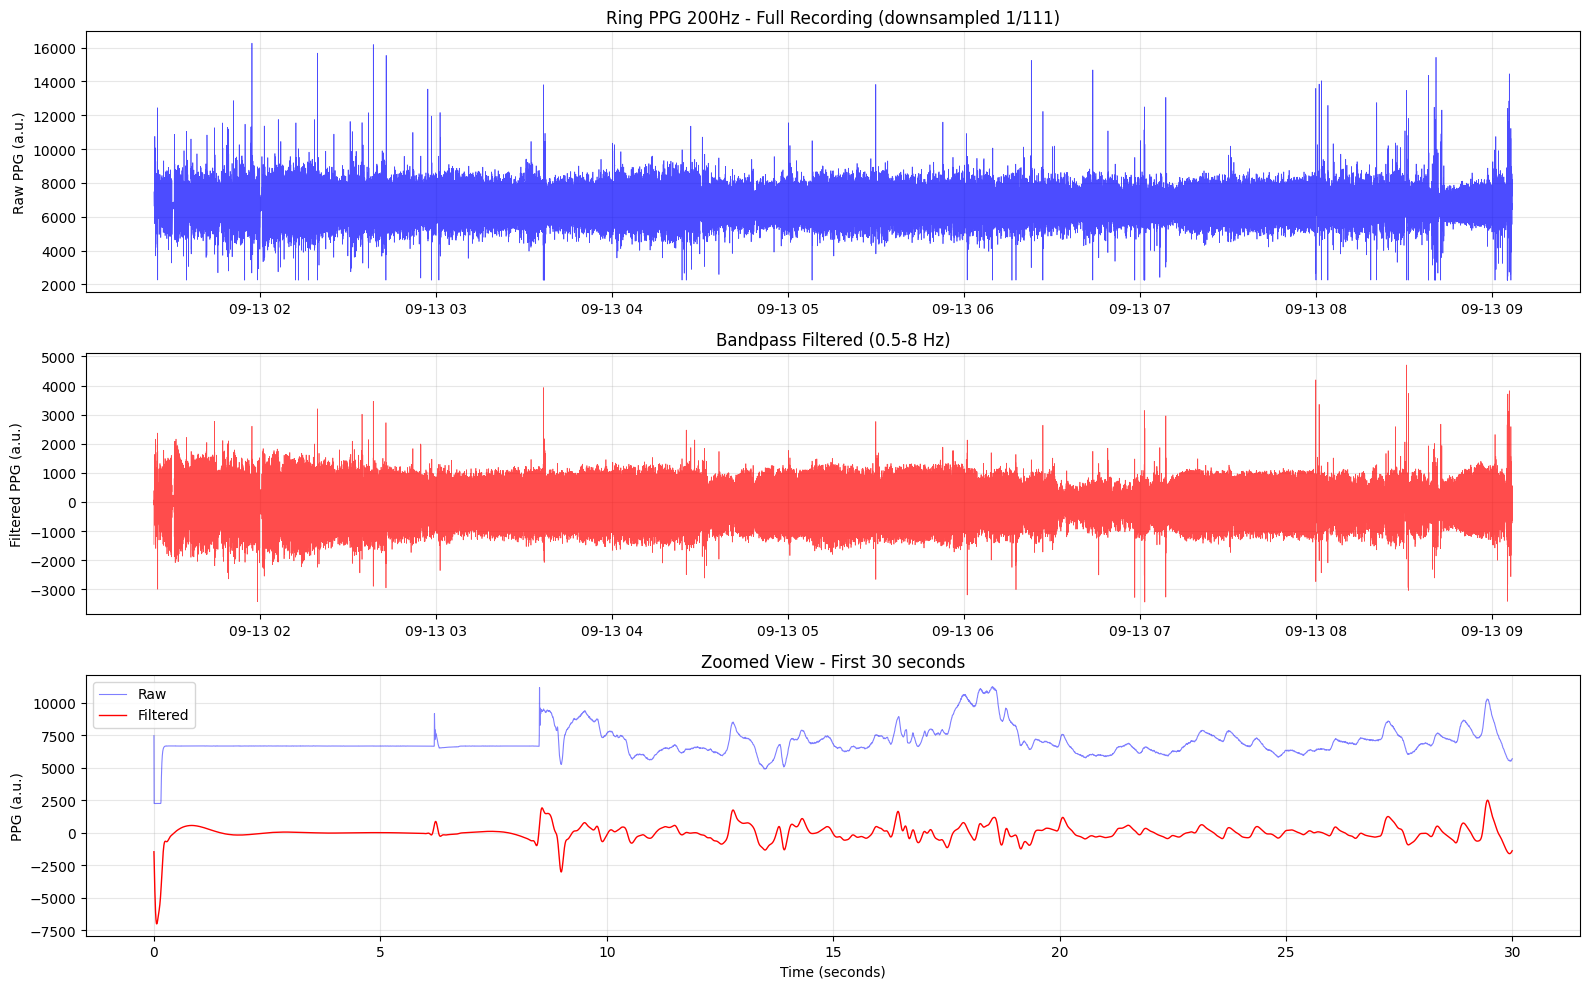

[Saved: ring_ppg_200hz_sections.png]


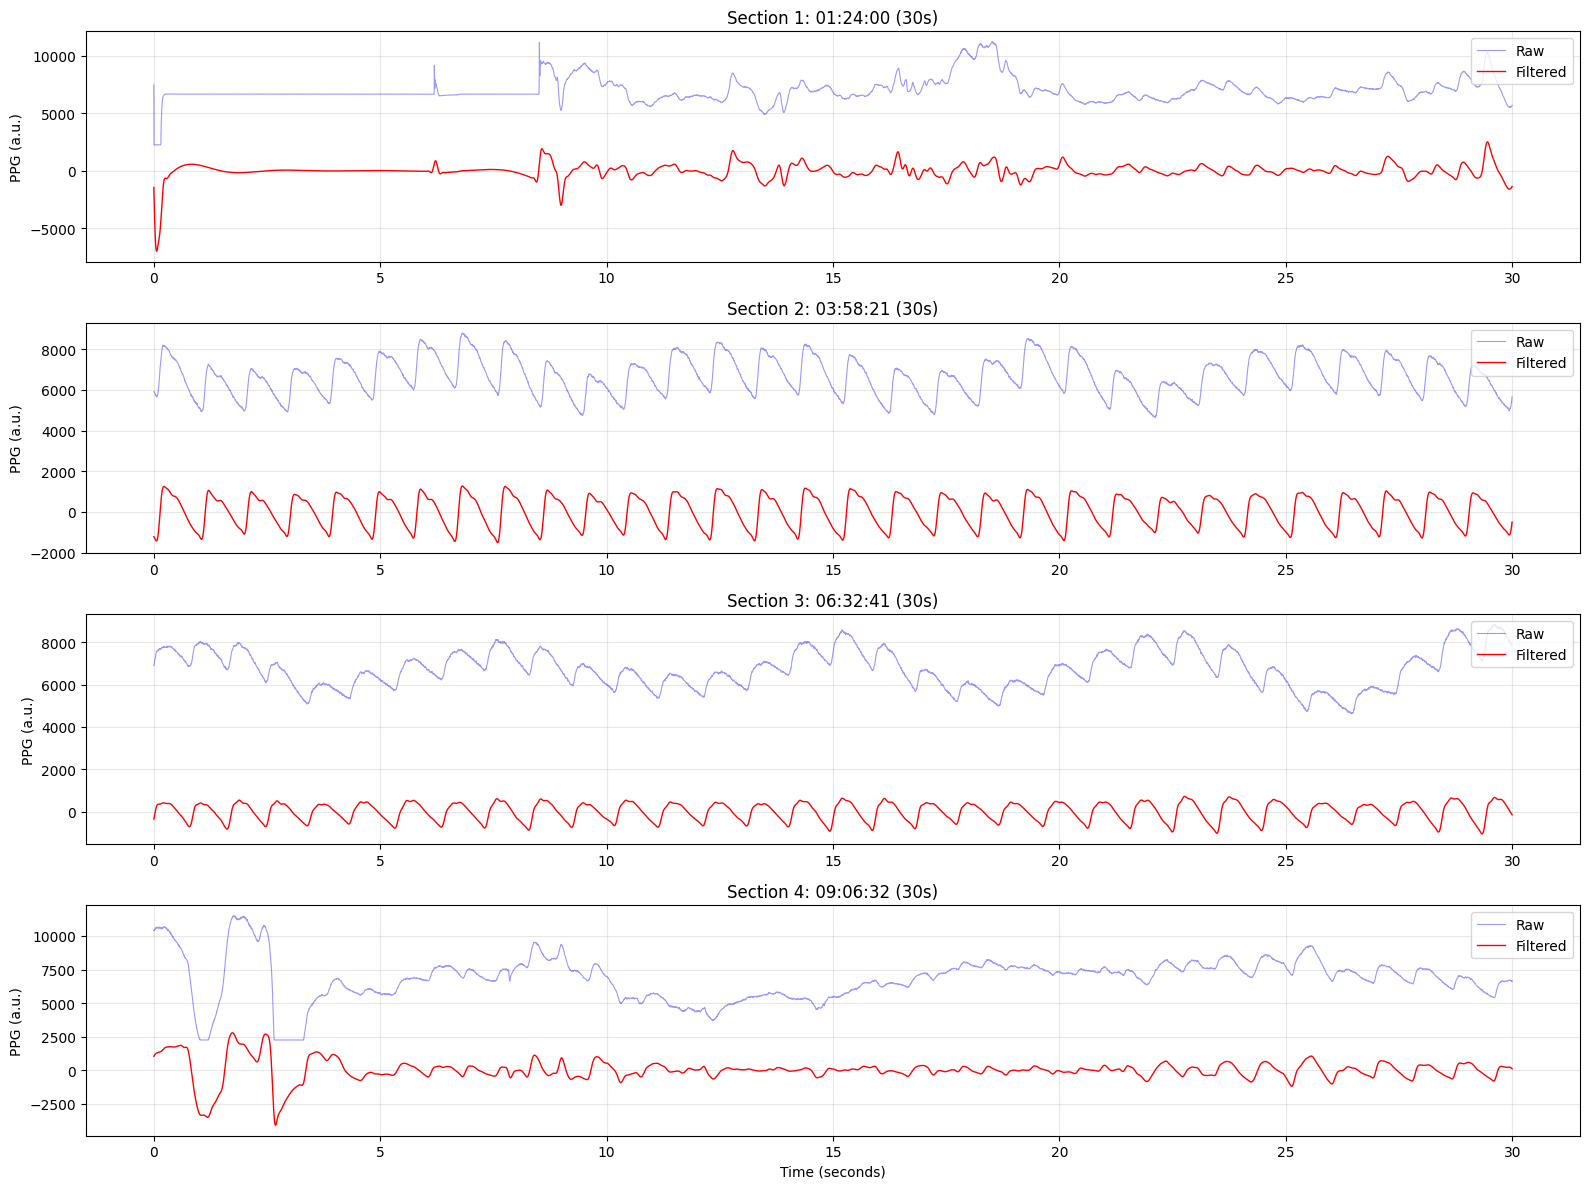


[Statistics]
Raw PPG:
  Mean:   6691.57
  Std:    1019.08
  Min:    2247.00
  Max:    16284.00

Filtered PPG:
  Mean:   -3.12e-02
  Std:    732.85
  Min:    -7009.35
  Max:    5048.41

Visualization Complete!


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend

# ============================================================
# CONFIG
# ============================================================
RING_CSV = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw2.csv"
FS_RING = 200.0
RING_START_TIME = "2025-09-13 01:24:00"

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def read_csv_robust(path: str) -> pd.DataFrame:
    """CSV 읽기 - 헤더 자동 감지"""
    df = pd.read_csv(path)
    def is_numberish(x):
        try:
            float(str(x).strip())
            return True
        except: return False
    if df.shape[1] >= 2 and all(is_numberish(c) for c in df.columns):
        df = pd.read_csv(path, header=None)
    return df

def build_datetime_from_us(df: pd.DataFrame, time_col: str, start_time: str) -> pd.Series:
    """마이크로초 타임스탬프를 datetime으로 변환"""
    ts = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)
    ts = np.asarray(ts, dtype=float)

    # 마이크로초 단위로 가정
    t_seconds = (ts - ts[0]) / 1e6
    t_seconds = np.nan_to_num(t_seconds, nan=0.0)

    dt = pd.to_datetime(start_time) + pd.to_timedelta(t_seconds, unit='s')
    return pd.Series(dt)

def preprocess_ppg(x: np.ndarray, fs: float, lowcut: float = 0.5, highcut: float = 8.0) -> np.ndarray:
    """PPG 전처리: detrend + bandpass filter"""
    if np.any(~np.isfinite(x)):
        x = pd.Series(x).interpolate(limit_direction="both").to_numpy(dtype=float)

    # Detrend
    x0 = detrend(x)

    # Bandpass filter
    nyq = 0.5 * fs
    lo = max(lowcut / nyq, 1e-6)
    hi = min(highcut / nyq, 0.999)

    try:
        b, a = butter(4, [lo, hi], btype="band")
        return filtfilt(b, a, x0)
    except:
        return x0

# ============================================================
# LOAD DATA
# ============================================================
print("="*80)
print("Ring PPG 200Hz - Full Waveform Visualization")
print("="*80)

df = read_csv_robust(RING_CSV)
print(f"\n[Data Info]")
print(f"  Shape: {df.shape}")
print(f"  Columns: {df.columns.tolist()}")
print(f"  Duration: {len(df) / FS_RING:.1f} seconds ({len(df) / FS_RING / 3600:.2f} hours)")

# Time column (첫 번째 컬럼)
time_col = df.columns[0]
ppg_col = df.columns[1]

# Build datetime
dt = build_datetime_from_us(df, time_col, RING_START_TIME)
ppg_raw = pd.to_numeric(df[ppg_col], errors="coerce").to_numpy(dtype=float)

print(f"\n[Time Range]")
print(f"  Start: {dt.min()}")
print(f"  End:   {dt.max()}")
print(f"  Duration: {(dt.max() - dt.min()).total_seconds() / 3600:.2f} hours")

# Preprocess
print(f"\n[Preprocessing...]")
ppg_filtered = preprocess_ppg(ppg_raw, FS_RING)

# ============================================================
# VISUALIZATION
# ============================================================

# 1. 전체 파형 (다운샘플링)
print(f"\n[Plotting...]")
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

# Plot 1: Raw PPG (전체, 다운샘플링)
downsample_factor = max(1, len(ppg_raw) // 50000)  # 최대 50k 포인트
idx_down = np.arange(0, len(ppg_raw), downsample_factor)

ax = axes[0]
ax.plot(dt.iloc[idx_down], ppg_raw[idx_down], 'b-', alpha=0.7, linewidth=0.5)
ax.set_ylabel("Raw PPG (a.u.)")
ax.set_title(f"Ring PPG 200Hz - Full Recording (downsampled 1/{downsample_factor})")
ax.grid(True, alpha=0.3)

# Plot 2: Filtered PPG (전체, 다운샘플링)
ax = axes[1]
ax.plot(dt.iloc[idx_down], ppg_filtered[idx_down], 'r-', alpha=0.7, linewidth=0.5)
ax.set_ylabel("Filtered PPG (a.u.)")
ax.set_title("Bandpass Filtered (0.5-8 Hz)")
ax.grid(True, alpha=0.3)

# Plot 3: Zoomed view (첫 30초)
zoom_duration = 30  # seconds
zoom_samples = int(zoom_duration * FS_RING)
zoom_idx = slice(0, min(zoom_samples, len(ppg_raw)))

ax = axes[2]
t_sec = np.arange(len(ppg_filtered[zoom_idx])) / FS_RING
ax.plot(t_sec, ppg_raw[zoom_idx], 'b-', alpha=0.5, linewidth=0.8, label='Raw')
ax.plot(t_sec, ppg_filtered[zoom_idx], 'r-', linewidth=1.0, label='Filtered')
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("PPG (a.u.)")
ax.set_title(f"Zoomed View - First {zoom_duration} seconds")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ring_ppg_200hz_full_waveform.png", dpi=150, bbox_inches='tight')
print("[Saved: ring_ppg_200hz_full_waveform.png]")
plt.show()

# ============================================================
# 2. 시간대별 샘플링 (여러 구간)
# ============================================================
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# 4개 구간: 처음, 1/3, 2/3, 끝
section_duration = 30  # seconds
section_samples = int(section_duration * FS_RING)

positions = [
    0,  # 시작
    len(ppg_raw) // 3,  # 1/3 지점
    2 * len(ppg_raw) // 3,  # 2/3 지점
    max(0, len(ppg_raw) - section_samples)  # 끝
]

for i, start_idx in enumerate(positions):
    end_idx = min(start_idx + section_samples, len(ppg_raw))
    section_slice = slice(start_idx, end_idx)

    t_sec = np.arange(len(ppg_filtered[section_slice])) / FS_RING
    section_time = dt.iloc[start_idx]

    ax = axes[i]
    ax.plot(t_sec, ppg_raw[section_slice], 'b-', alpha=0.4, linewidth=0.8, label='Raw')
    ax.plot(t_sec, ppg_filtered[section_slice], 'r-', linewidth=1.0, label='Filtered')
    ax.set_ylabel("PPG (a.u.)")
    ax.set_title(f"Section {i+1}: {section_time.strftime('%H:%M:%S')} ({section_duration}s)")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.savefig("ring_ppg_200hz_sections.png", dpi=150, bbox_inches='tight')
print("[Saved: ring_ppg_200hz_sections.png]")
plt.show()

# ============================================================
# 3. 통계 정보
# ============================================================
print("\n" + "="*80)
print("[Statistics]")
print("="*80)
print(f"Raw PPG:")
print(f"  Mean:   {np.nanmean(ppg_raw):.2f}")
print(f"  Std:    {np.nanstd(ppg_raw):.2f}")
print(f"  Min:    {np.nanmin(ppg_raw):.2f}")
print(f"  Max:    {np.nanmax(ppg_raw):.2f}")
print(f"\nFiltered PPG:")
print(f"  Mean:   {np.nanmean(ppg_filtered):.2e}")
print(f"  Std:    {np.nanstd(ppg_filtered):.2f}")
print(f"  Min:    {np.nanmin(ppg_filtered):.2f}")
print(f"  Max:    {np.nanmax(ppg_filtered):.2f}")
print("\n" + "="*80)
print("Visualization Complete!")
print("="*80)